# Dataset exploration

Loads one batch from each of the four SenseFi benchmark datasets and
visualizes CSI amplitude. Run from the `notebooks/` directory.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from rfsensing import data

DATA_DIR = Path.cwd().resolve().parents[2] / "data"
print(f"data root: {DATA_DIR} (exists: {DATA_DIR.exists()})")
print(f"registered datasets: {data.list_available()}")

data root: /Users/ygglc/Work/Projects/WiFi-Sensing/data (exists: True)
registered datasets: ['ntu_fi_har', 'ntu_fi_humanid', 'synthetic', 'ut_har', 'widar']


## Shapes and classes

In [2]:
DATASETS = ["ut_har", "ntu_fi_har", "ntu_fi_humanid", "widar"]
modules = {}
for name in DATASETS:
    dm = data.build(name, root=DATA_DIR, batch_size=4)
    dm.setup("fit")
    modules[name] = dm
    x, y = next(iter(dm.train_dataloader()))
    print(
        f"{name:16s} x{tuple(x.shape)}  classes={dm.num_classes:3d}  "
        f"first classes: {dm.class_names[:4]}"
    )

ut_har           x(4, 1, 250, 90)  classes=  7  first classes: ['activity_0', 'activity_1', 'activity_2', 'activity_3']
ntu_fi_har       x(4, 3, 114, 500)  classes=  6  first classes: ['box', 'circle', 'clean', 'fall']
ntu_fi_humanid   x(4, 3, 114, 500)  classes= 14  first classes: ['001', '002', '003', '004']


widar            x(4, 22, 20, 20)  classes= 22  first classes: ['Push&Pull', 'Sweep', 'Clap', 'Slide']


## UT-HAR: amplitude over time

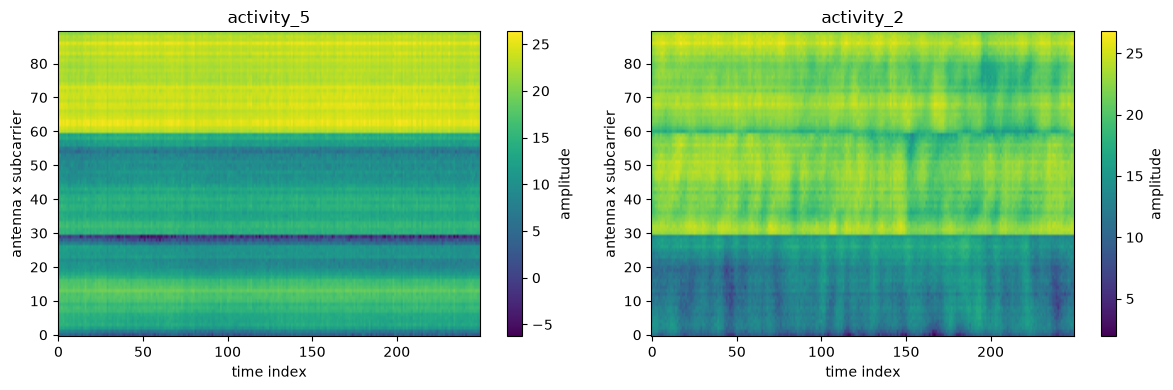

In [3]:
dm = modules["ut_har"]
x, y = next(iter(dm.train_dataloader()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, i in zip(axes, range(2)):
    im = ax.imshow(x[i, 0].T, aspect="auto", origin="lower", cmap="viridis")
    ax.set_xlabel("time index")
    ax.set_ylabel("antenna x subcarrier")
    ax.set_title(dm.class_names[int(y[i])])
    fig.colorbar(im, ax=ax, label="amplitude")
fig.tight_layout()

## NTU-Fi HAR: normalized amplitude heatmap

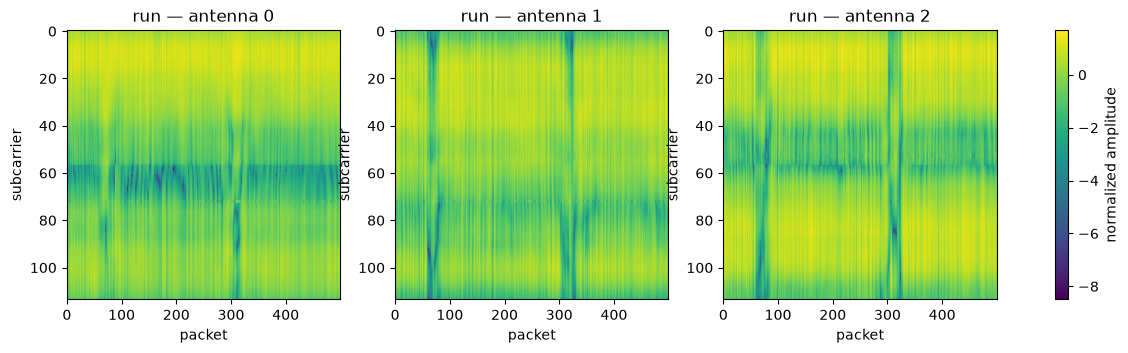

In [4]:
dm = modules["ntu_fi_har"]
x, y = next(iter(dm.train_dataloader()))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, antenna in zip(axes, range(3)):
    im = ax.imshow(x[0, antenna], aspect="auto", cmap="viridis")
    ax.set_xlabel("packet")
    ax.set_ylabel("subcarrier")
    ax.set_title(f"{dm.class_names[int(y[0])]} — antenna {antenna}")
fig.colorbar(im, ax=axes, label="normalized amplitude")

## Widar: BVP time steps

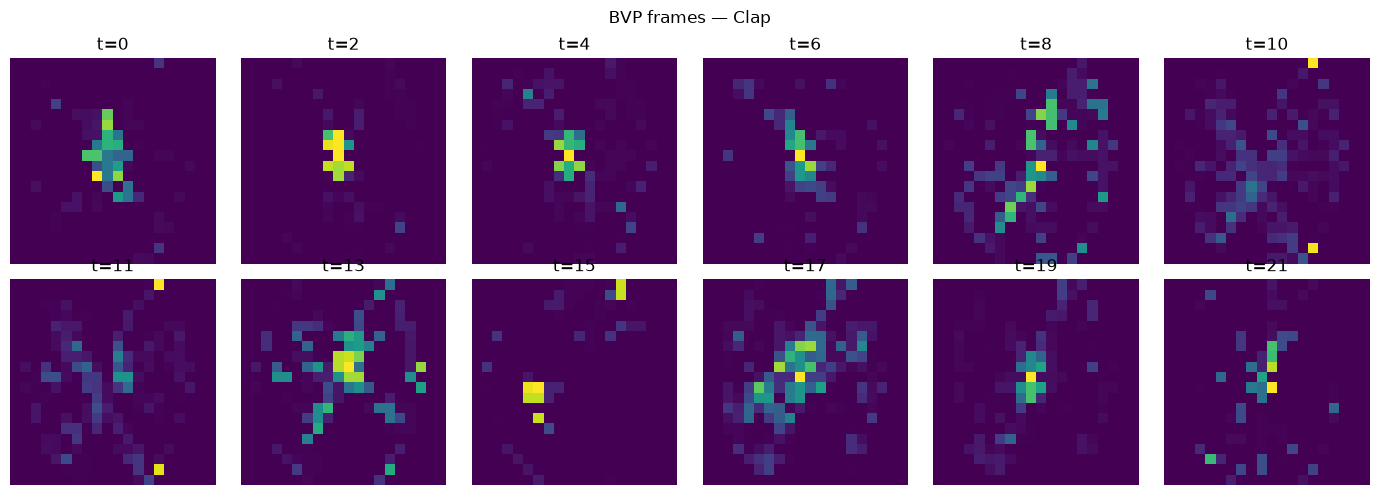

In [5]:
dm = modules["widar"]
x, y = next(iter(dm.train_dataloader()))
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
frames = [round(i * 21 / 11) for i in range(12)]  # 12 frames spanning t=0..21
for frame, ax in zip(frames, axes.flat):
    ax.imshow(x[0, frame], cmap="viridis")
    ax.set_title(f"t={frame}")
    ax.axis("off")
fig.suptitle(f"BVP frames — {dm.class_names[int(y[0])]}")
fig.tight_layout()